# ks_base_solution.ipynb --- example code for simulating and reduced-order modeling the Kuramoto-Sivashinsky equation on the spectral-based and the cubic-spline-based grid for the base traveling-wave solution

# Step 1. Build the grid and KS object

In [1]:
import os
import shutil
import pickle

import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

import configs
from SROpInf.grids.grid1d import Grid1DUniformSpectral
from SROpInf.models.ks import KuramotoSivashinsky
from SROpInf.dataloader import FOMDataloader

from plot import plot_results

params = configs.load_configs()
assert params.base_path.rstrip("/").endswith("ks_base_solution"), \
    f"Expected configs to point at output/ks_base_solution, got {params.base_path}"
assert params.type_traj_training == "base_solution", \
    f"Expected type_traj_training='base_solution', got {params.type_traj_training!r}"
assert params.pod_energy_threshold == 0.9999, \
    f"Expected pod_energy_threshold=0.9999, got {params.pod_energy_threshold!r}"
dataloader = FOMDataloader(params)
grid = Grid1DUniformSpectral(params.Lx, params.nx)
fom  = KuramotoSivashinsky(grid, params.nu)
stepper = fom.get_stepper(method="rk3cn", dt=params.dt)

# Step 2. Create the initial condition of the base solution and collect the training data

In [2]:
if os.path.exists(params.fig_path_fom):
    shutil.rmtree(params.fig_path_fom)
    os.makedirs(params.fig_path_fom)
if os.path.exists(params.traj_path_fom):
    shutil.rmtree(params.traj_path_fom)
    os.makedirs(params.traj_path_fom)

# 1. Specify a benchmark initial condition:
x = grid.x

# Ensure a base IC that already sits on the KS attractor. If a precomputed one is not found,
# integrate a raw IC for a fixed burn-in horizon (T_burn_in, independent of params.T) to reach
# the attractor, then cache it. This keeps the notebook self-contained: there is no need to
# manually switch params.T between a one-off IC-generation run and the reconstruction run.
ic_file = params.data_path + "traj_init_base.npy"
try:
    q = np.load(ic_file)
except FileNotFoundError:
    T_burn_in = 120.0
    n_burn_in = int(T_burn_in / params.dt)
    print(f"No precomputed base IC found; generating one via a t={T_burn_in:g} burn-in integration...")
    q = -1 * np.sin(x) + 2 * np.cos(2 * x) + 3 * np.cos(3 * x) - 4 * np.sin(4 * x)
    for _ in tqdm(range(n_burn_in), desc="KS burn-in"):
        q = stepper.step(q)
    np.save(ic_file, q)
    print(f"Saved base IC (state on the attractor at t={T_burn_in:g}) to {ic_file}")

# Generate the base training trajectory over the reconstruction horizon params.T (= 10),
# starting from the cached attractor IC.
assert params.T == 10.0, f"Expected T=10.0 for the base-solution reconstruction, got {params.T}"
Q = np.zeros((params.nx, len(params.tsave)))

pbar = tqdm(range(len(params.time)), desc="KS FOM")
for idx_time in pbar:
    if idx_time % params.nsave == 0:
        Q[:, idx_time // params.nsave] = q
        pbar.set_postfix(t=f"{idx_time*params.dt:.1f}", norm=f"{grid.norm(q):.2f}")
    q = stepper.step(q)

# Perceptually-uniform diverging colormap (Cynthia Brewer's RdBu, reversed) centered at u=0;
# filled contours (41 levels) of the chaotic field.
# vlim = float(np.ceil(np.max(np.abs(Q))))
vlim = 15
fig, ax = plt.subplots(figsize=(10, 6))
pm = ax.contourf(
    grid.x, params.tsave, Q.T,
    levels=np.linspace(-vlim, vlim, 41),
    cmap="RdBu_r", vmin=-vlim, vmax=vlim)
# ax.set_xlabel(r"$x$", fontsize=20)
# ax.set_ylabel(r"$t$", fontsize=20)
# ax.set_title(r"Kuramoto--Sivashinsky $u(x, t)$", fontsize=18)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_xlim(0, grid.Lx)
ax.tick_params(labelsize=20)
cbar = fig.colorbar(pm, ax=ax, ticks=[-15, -10, -5, 0, 5, 10, 15])
# cbar.set_label(r"$u$", fontsize=20)
cbar.ax.tick_params(labelsize=20)
plt.savefig(params.fig_path_fom + "traj_base.png", dpi=300)
plt.savefig(params.fig_path_fom + "traj_base.eps", dpi=300)
plt.close()

# Based on the base IC associated with the traveling wave, create 10 perturbed ICs by adding small random harmonics.
q_base = np.load(params.data_path + "traj_init_base.npy")
q_base_norm = grid.norm(q_base)
k_min = 2
k_max = int(np.floor(np.sqrt(1 / params.nu))) # ranges from k = 2 to k_max where k_max is the max wavenumber keeping (1 - nu * k_max^2) > 0, i.e. linearly unstable modes

q_list = []

print("Using the base IC to generate 1 training trajectory...")
idx_traj = 0
np.save(params.fname_traj_init % idx_traj, q_base)        
np.save(params.fname_time, params.tsave)
np.save(params.fname_traj % ("fom", idx_traj), Q)
np.save(params.fname_traj_scaled % ("fom", idx_traj), grid.apply_sqrt_inner_product_mass(Q))

# vlim = float(np.ceil(np.max(np.abs(Q))))
vlim = 15
fig, ax = plt.subplots(figsize=(10, 6))
pm = ax.contourf(
    grid.x, params.tsave, Q.T,
    levels=np.linspace(-vlim, vlim, 21),
    cmap="RdBu_r", vmin=-vlim, vmax=vlim)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_xlim(0, grid.Lx)
ax.tick_params(labelsize=20)
cbar = fig.colorbar(pm, ax=ax, ticks=[-15, -10, -5, 0, 5, 10, 15])
cbar.ax.tick_params(labelsize=20)
plt.tight_layout()
plt.savefig(params.fig_path_fom + "traj_%03d.png" % idx_traj, dpi=300)
plt.savefig(params.fig_path_fom + "traj_%03d.eps" % idx_traj, dpi=300)
plt.close()

No precomputed base IC found; generating one via a t=120 burn-in integration...


KS burn-in:   0%|          | 0/120000 [00:00<?, ?it/s]

Saved base IC (state on the attractor at t=120) to /Users/yushuai/Documents/sr-opinf/output/ks_base_solution/data/traj_init_base.npy


KS FOM:   0%|          | 0/10001 [00:00<?, ?it/s]

Using the base IC to generate 1 training trajectory...


# Step 3. Perform template fitting and symmetry-reduced POD

Performing template fitting for traj  0...
Performing POD with tentative r=16...


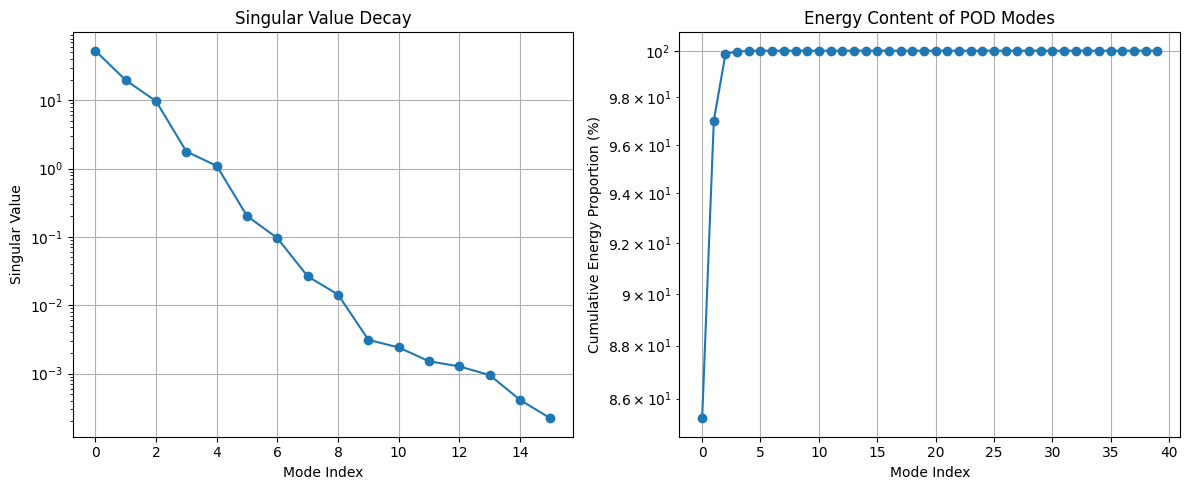

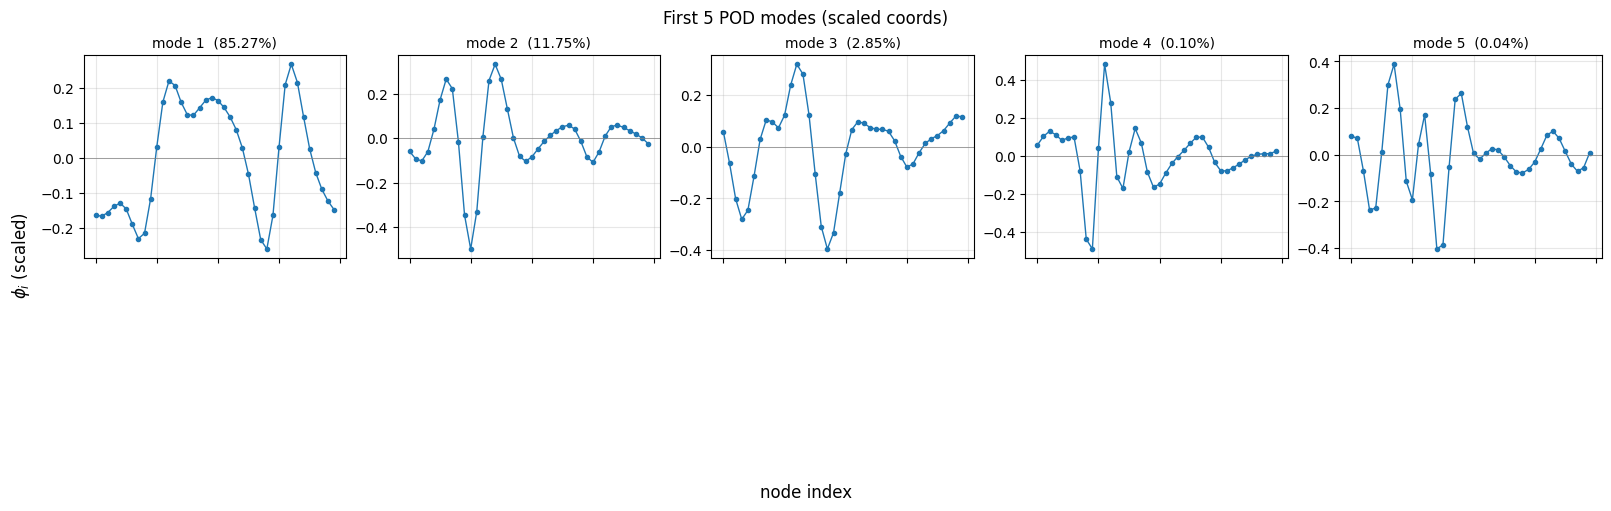

Energy proportion of the selected 5 modes: 99.998453%
Square root of energy loss = 0.3933%
Projection error: 0.3933%
Projection error expected from Eckart-Young Theorem: 0.3933%


In [3]:
from SROpInf.sr_tools import template_fitting
from SROpInf.mode_decomposition import pod
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel

# Assign the template to be q_template = cos(2πx/L) for global, traveling wave
q_template = np.cos(2 * np.pi * grid.x / grid.Lx)
q_template_perp = np.sin(2 * np.pi * grid.x / grid.Lx)
q_template_scaled = grid.apply_sqrt_inner_product_mass(q_template)
q_template_perp_scaled = grid.apply_sqrt_inner_product_mass(q_template_perp)
q_template_dx_scaled = grid.diff_x(q_template_scaled)
q_template_dxx_scaled = grid.diff_x(q_template_scaled, order=2)

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled
)

np.save(params.data_path + "q_template.npy", q_template)
np.save(params.data_path + "q_template_perp.npy", q_template_perp)
np.save(params.data_path + "q_template_scaled.npy", q_template_scaled)
np.save(params.data_path + "q_template_perp_scaled.npy", q_template_perp_scaled)

Q_fitted_scaled_all = np.zeros((q_template.shape[0], len(params.tsave), params.num_traj_training))

for idx_traj in range(params.num_traj_training):
    print(f"Performing template fitting for traj {idx_traj:2d}...")
    Q = dataloader.get_traj(which_traj = idx_traj, which_snapshot = range(len(params.tsave)))
    Q_fitted, c = template_fitting(Q = Q, grid = grid, q_template = q_template, q_template_perp = q_template_perp)
    Q_fitted_scaled = grid.apply_sqrt_inner_product_mass(Q_fitted)
    
    inv_shift_speed_denom = fom_sr.inv_shift_speed_denom(Q_fitted_scaled)
    
    np.save(params.fname_traj_fitted % ("fom", idx_traj), Q_fitted)
    np.save(params.fname_traj_fitted_scaled % ("fom", idx_traj), Q_fitted_scaled)
    np.save(params.fname_traj_init_fitted_scaled % idx_traj, Q_fitted_scaled[:, 0])
    
    # also save right-hand-side terms for operator inference
    np.save(params.fname_rhs_fitted_scaled % ("fom", idx_traj), fom.rhs_scaled(Q_fitted_scaled))
    np.save(params.fname_shift_amount % ("fom", idx_traj), c)
    np.save(params.fname_inv_shift_speed_denom % ("fom", idx_traj), inv_shift_speed_denom)
    
    Q_fitted_scaled_all[:, :, idx_traj] = Q_fitted_scaled
    
    # Diagnostic: plot the inverse shift-speed denominator 1/D vs t. fom_sr returns the
    # unregularized 1/D; a spike (D -> 0) flags a near-singular shift-speed event. The ROM
    # class regularizes it as D/(D^2 + tau^2), but the FOM quantity plotted here is plain 1/D.
    tau = params.shift_speed_denom_threshold
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(params.tsave, inv_shift_speed_denom, lw=1, label=r"$1/D$")
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"inv. shift-speed denom.")
    ax.set_title(f"KS FOM traj {idx_traj:2d}: inv_shift_speed_denom (τ={tau:.1e})")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.savefig(params.fig_path_fom + "inv_shift_speed_denom_%03d.png" % idx_traj, dpi=300)
    plt.close()
    
    vlim = 15
    fig, ax = plt.subplots(figsize=(10, 6))
    pm = ax.contourf(
        grid.x, params.tsave, Q_fitted.T,
        levels=np.linspace(-vlim, vlim, 21),
        cmap="RdBu_r", vmin=-vlim, vmax=vlim)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlim(0, grid.Lx)
    ax.tick_params(labelsize=20)
    cbar = fig.colorbar(pm, ax=ax, ticks=[-15, -10, -5, 0, 5, 10, 15])
    cbar.ax.tick_params(labelsize=20)
    plt.tight_layout()
    plt.savefig(params.fig_path_fom + "traj_fitted_%03d.png" % idx_traj, dpi=300)
    plt.savefig(params.fig_path_fom + "traj_fitted_%03d.eps" % idx_traj, dpi=300)
    plt.close()
    
phi_scaled, r = pod(Q_scaled = Q_fitted_scaled_all.reshape(Q_fitted_scaled_all.shape[0], -1),
                    r_tentative = params.num_traj_training * 16,
                    cumulative_energy_ratio=params.pod_energy_threshold)

np.save(params.data_path + "phi_srpod.npy", phi_scaled)

# Step 4. S-R POD-Galerkin ROM via Galerkin projection onto the S-R POD subspace
# (for the base-solution case, 5 S-R POD modes, relative RMSE = 6.12%)

In [4]:
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled.npy")
q_template_dx_scaled = grid.diff_x(q_template_scaled)
q_template_dxx_scaled = grid.diff_x(q_template_dx_scaled)

if os.path.exists(params.fig_path_srpodgal_spec):
    shutil.rmtree(params.fig_path_srpodgal_spec)
    os.makedirs(params.fig_path_srpodgal_spec)
if os.path.exists(params.traj_path_srpodgal_spec):
    shutil.rmtree(params.traj_path_srpodgal_spec)
    os.makedirs(params.traj_path_srpodgal_spec)

c_fom = '#000000'
c_srpodgal = '#6A3D9A'
l_fom = '-'
l_srpodgal = '-'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}
                   
model_name_list = ["FOM", "S-R Galerkin ROM (on spectral-based grid)"]
model_abbrev_list = ["fom", "srpodgal_spectral"]
color_list = [c_fom, c_srpodgal]
linestyle_list = [l_fom, l_srpodgal]

plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

rom_srpodgal = fom_sr.project(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom", idx_traj))[0]
    z0 = rom_srpodgal.full_to_latent(q0_fitted_scaled)
    output_list = rom_srpodgal.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_srpodgal_spec,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )

Simulating S-R Galerkin ROM (on spectral-based grid) traj  0...
Traj 0: relative RMSE 12.61%


# Step 5. S-R OpInf ROM with training data reprojected onto the S-R POD subspace

In [ ]:
from SROpInf.sr_tools import sropinf
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel, SymmetryReducedScaledReducedOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled.npy")
q_template_dx_scaled = grid.diff_x(q_template_scaled)
q_template_dxx_scaled = grid.diff_x(q_template_dx_scaled)

if os.path.exists(params.fig_path_sropinf_spec_reproj):
    shutil.rmtree(params.fig_path_sropinf_spec_reproj)
    os.makedirs(params.fig_path_sropinf_spec_reproj)
if os.path.exists(params.traj_path_sropinf_spec_reproj):
    shutil.rmtree(params.traj_path_sropinf_spec_reproj)
    os.makedirs(params.traj_path_sropinf_spec_reproj)

c_fom = '#000000'
c_srpodgal = '#6A3D9A'
c_sropinf_reproj = '#FF7F00'
l_fom = '-'
l_srpodgal = '-'
l_sropinf_reproj = '--'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}
                   
model_name_list = ["FOM", "S-R Galerkin ROM (on spectral-based grid)", "S-R OpInf ROM (re-projected data, on spectral-based grid)"]
model_abbrev_list = ["fom", "srpodgal_spectral", "sropinf_spectral_reproj"]
color_list = [c_fom, c_srpodgal, c_sropinf_reproj]
linestyle_list = [l_fom, l_srpodgal, l_sropinf_reproj]

plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

# 1. Load the dataset for training of S-R OpInf
Q_fitted_scaled = dataloader.get_traj(
    which_traj = range(params.num_traj_training),
    which_snapshot = range(len(params.tsave)),
    is_scaled = True,
    is_template_fitted = True
)

tensors_sropinf_reproj = sropinf(
    poly_comp = params.poly_comp,
    Phi = phi_scaled,
    Q_fitted = Q_fitted_scaled,
    fom_sr = fom_sr,
    re_projection_option = True
)

rom_sropinf_reproj = SymmetryReducedScaledReducedOrderModel.build(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled,
    tensors = tensors_sropinf_reproj,
    q_template_dxx_scaled = q_template_dxx_scaled,
    shift_func = fom_sr.shift_x,
    shift_speed_denom_threshold = params.shift_speed_denom_threshold
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom", idx_traj))[0]
    z0 = rom_sropinf_reproj.full_to_latent(q0_fitted_scaled)
    output_list = rom_sropinf_reproj.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_sropinf_spec_reproj,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )
    
with open(params.data_path + "tensors_sropinf_spectral_reproj.pkl", "wb") as f:
    pickle.dump(tensors_sropinf_reproj, f)

# Step 6. S-R OpInf ROM
# (blow up at t = 1.8)

In [ ]:
from SROpInf.sr_tools import sropinf
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel, SymmetryReducedScaledReducedOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled.npy")
q_template_dx_scaled = grid.diff_x(q_template_scaled)
q_template_dxx_scaled = grid.diff_x(q_template_dx_scaled)

if os.path.exists(params.fig_path_sropinf_spec):
    shutil.rmtree(params.fig_path_sropinf_spec)
    os.makedirs(params.fig_path_sropinf_spec)
if os.path.exists(params.traj_path_sropinf_spec):
    shutil.rmtree(params.traj_path_sropinf_spec)
    os.makedirs(params.traj_path_sropinf_spec)

c_fom = '#000000'
c_srpodgal = '#6A3D9A'
c_sropinf_reproj = '#FF7F00'
c_sropinf = '#E31A1C'
l_fom = '-'
l_srpodgal = '-'
l_sropinf_reproj = '--'
l_sropinf = '-'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}
                   
model_name_list = ["FOM", "S-R Galerkin ROM (on spectral-based grid)", "S-R OpInf ROM (re-projected data, on spectral-based grid)",
                    "S-R OpInf ROM (on spectral-based grid)"]
model_abbrev_list = ["fom", "srpodgal_spectral", "sropinf_spectral_reproj", "sropinf_spectral"]
color_list = [c_fom, c_srpodgal, c_sropinf_reproj, c_sropinf]
linestyle_list = [l_fom, l_srpodgal, l_sropinf_reproj, l_sropinf]

plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

# 1. Load the dataset for training of S-R OpInf
Q_fitted_scaled = dataloader.get_traj(
    which_traj = range(params.num_traj_training),
    which_snapshot = range(len(params.tsave)),
    is_scaled = True,
    is_template_fitted = True
)

tensors_sropinf = sropinf(
    poly_comp = params.poly_comp,
    Phi = phi_scaled,
    Q_fitted = Q_fitted_scaled,
    fom_sr = fom_sr,
    re_projection_option = False
)

rom_sropinf = SymmetryReducedScaledReducedOrderModel.build(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled,
    tensors = tensors_sropinf,
    q_template_dxx_scaled = q_template_dxx_scaled,
    shift_func = fom_sr.shift_x,
    shift_speed_denom_threshold = params.shift_speed_denom_threshold
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom", idx_traj))[0]
    z0 = rom_sropinf.full_to_latent(q0_fitted_scaled)
    output_list = rom_sropinf.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_sropinf_spec,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )
    
with open(params.data_path + "tensors_sropinf_spectral.pkl", "wb") as f:
    pickle.dump(tensors_sropinf, f)

# Step 7. S-R OpInf ROM with the best grid-searched regularizer
# best regularizers (lambda_poly, lambda_dcdt_numer) = (1.56e-1, 6.90e-6), relative RMSE = 2.22%

In [ ]:
from SROpInf.sr_tools import sropinf
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel, SymmetryReducedScaledReducedOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled.npy")
q_template_dx_scaled = grid.diff_x(q_template_scaled)
q_template_dxx_scaled = grid.diff_x(q_template_dx_scaled)

if os.path.exists(params.fig_path_sropinf_spec_reg):
    shutil.rmtree(params.fig_path_sropinf_spec_reg)
    os.makedirs(params.fig_path_sropinf_spec_reg)
if os.path.exists(params.traj_path_sropinf_spec_reg):
    shutil.rmtree(params.traj_path_sropinf_spec_reg)
    os.makedirs(params.traj_path_sropinf_spec_reg)
    
assert params.opinf_penalty_weight_rhs_poly == 1.56e-1, f"Expected optimal penalty for the polynomial RHS part lambda_poly = 1.56e-1, got {params.opinf_penalty_weight_rhs_poly}"
assert params.opinf_penalty_weight_dcdt_numer == 6.90e-6, f"Expected positive penalty for the numerator of the reconstruction equation lambda_dcdt = 6.90e-6, got {params.opinf_penalty_weight_dcdt_numer}"

c_fom = '#000000'
c_srpodgal = '#6A3D9A'
c_sropinf_reproj = '#FF7F00'
c_sropinf = '#E31A1C'
c_sropinf_reg = '#33A02C'
l_fom = '-'
l_srpodgal = '-'
l_sropinf_reproj = '--'
l_sropinf = '-'
l_sropinf_reg = '--'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}
                   
model_name_list = ["FOM", "S-R Galerkin ROM", "S-R OpInf ROM (trained with re-projected data)",
                    "S-R OpInf ROM", "S-R OpInf ROM (optimal penalty weights)"]
model_abbrev_list = ["fom", "srpodgal_spectral", "sropinf_spectral_reproj", "sropinf_spectral", "sropinf_spectral_regularized"]
color_list = [c_fom, c_srpodgal, c_sropinf_reproj, c_sropinf, c_sropinf_reg]
linestyle_list = [l_fom, l_srpodgal, l_sropinf_reproj, l_sropinf, l_sropinf_reg]

plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

# 1. Load the dataset for training of S-R OpInf
Q_fitted_scaled = dataloader.get_traj(
    which_traj = range(params.num_traj_training),
    which_snapshot = range(len(params.tsave)),
    is_scaled = True,
    is_template_fitted = True
)

c = dataloader.get_shift_amount(
    which_traj = range(params.num_traj_training),
    which_snapshot = range(len(params.tsave))
)

tensors_sropinf_reg = sropinf(
    poly_comp = params.poly_comp,
    Phi = phi_scaled,
    Q_fitted = Q_fitted_scaled,
    fom_sr = fom_sr,
    re_projection_option = False,
    grid_search_option = False,
    cross_validation_option = False,
    penalty_weight_rhs_poly = params.opinf_penalty_weight_rhs_poly,
    penalty_weight_dcdt_numer = params.opinf_penalty_weight_dcdt_numer,
    t_eval = params.tsave,
    shift_amount = c,
    fig_path = params.fig_path_sropinf_spec_reg,
)

rom_sropinf_reg = SymmetryReducedScaledReducedOrderModel.build(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled,
    tensors = tensors_sropinf_reg,
    q_template_dxx_scaled = q_template_dxx_scaled,
    shift_func = fom_sr.shift_x,
    shift_speed_denom_threshold = params.shift_speed_denom_threshold
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom", idx_traj))[0]
    z0 = rom_sropinf_reg.full_to_latent(q0_fitted_scaled)
    output_list = rom_sropinf_reg.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_sropinf_spec_reg,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )
    
with open(params.data_path + "tensors_sropinf_spectral_regularized.pkl", "wb") as f:
    pickle.dump(tensors_sropinf_reg, f)

# Step 8: Reset the grid to cubic-spline-interpolated grid.
# (The original FOM snapshots need not regenerating)

In [5]:
import os
import shutil
import pickle

import numpy as np
from matplotlib import pyplot as plt

import configs
from SROpInf.grids.grid1d import Grid1DUniformSpectral, Grid1DCubicSpline
from SROpInf.models.ks import KuramotoSivashinsky
from SROpInf.dataloader import FOMDataloader

from plot import plot_results

params = configs.load_configs()
grid = Grid1DUniformSpectral(params.Lx, params.nx)
fom = KuramotoSivashinsky(grid, params.nu)
# Notice that the black-boxed FOM is still spectral-based;
# but when we formulate s-r fom and template-fitting, symmetry-reducing additional advection term, etc.
# we use cubic-spline-interpolated shift operator and diff_x operator
x = grid.x
grid = Grid1DCubicSpline(params.Lx, x) # Replace the spectral-based grid with a cubic spline-based grid that has the same points
dataloader = FOMDataloader(params)

# Step 9. Re-perform the template fitting and symmetry-reduced POD

Performing template fitting for traj  0...
Performing POD with tentative r=16...


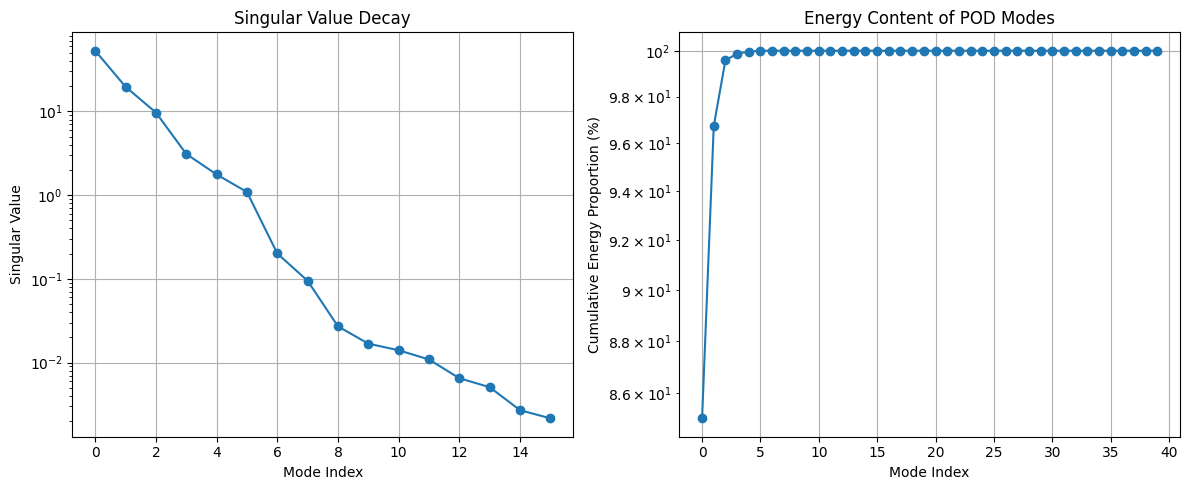

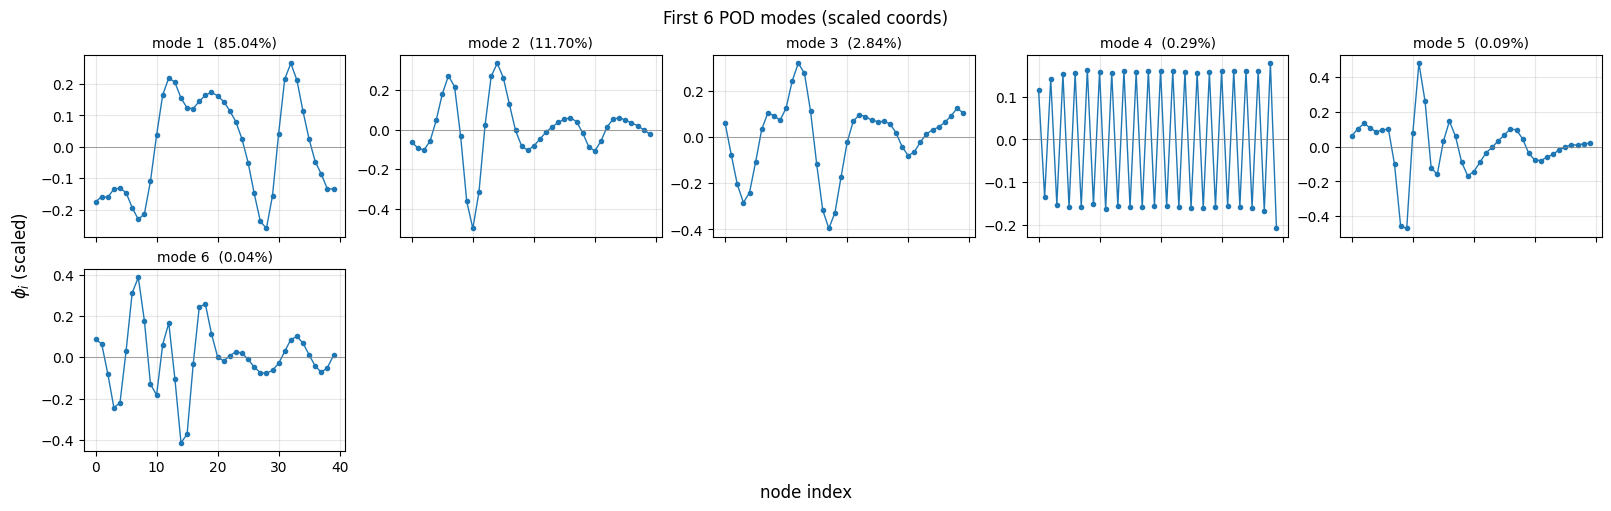

Energy proportion of the selected 6 modes: 99.998465%
Square root of energy loss = 0.3918%
Projection error: 0.3918%
Projection error expected from Eckart-Young Theorem: 0.3918%


In [6]:
from SROpInf.sr_tools import template_fitting
from SROpInf.mode_decomposition import pod
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel

# Assign the template to be q_template = cos(2πx/L) for global, traveling wave
q_template = np.cos(2 * np.pi * grid.x / grid.Lx)
q_template_perp = np.sin(2 * np.pi * grid.x / grid.Lx)
q_template_scaled = grid.apply_sqrt_inner_product_mass(q_template)
q_template_perp_scaled = grid.apply_sqrt_inner_product_mass(q_template_perp)
q_template_dx_scaled = grid.apply_sqrt_inner_product_mass(grid.diff_x(q_template))
q_template_dxx_scaled = grid.apply_sqrt_inner_product_mass(grid.diff_x(q_template, order=2))

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled
)

np.save(params.data_path + "q_template_cubic_spline.npy", q_template)
np.save(params.data_path + "q_template_perp_cubic_spline.npy", q_template_perp)
np.save(params.data_path + "q_template_scaled_cubic_spline.npy", q_template_scaled)
np.save(params.data_path + "q_template_perp_scaled_cubic_spline.npy", q_template_perp_scaled)
np.save(params.data_path + "q_template_dx_scaled_cubic_spline.npy", q_template_dx_scaled)
np.save(params.data_path + "q_template_dxx_scaled_cubic_spline.npy", q_template_dxx_scaled)

Q_fitted_scaled_all = np.zeros((q_template.shape[0], len(params.tsave), params.num_traj_training))

for idx_traj in range(params.num_traj_training):
    print(f"Performing template fitting for traj {idx_traj:2d}...")
    Q = dataloader.get_traj(which_traj = idx_traj, which_snapshot = range(len(params.tsave)))
    Q_scaled = grid.apply_sqrt_inner_product_mass(Q)
    Q_fitted, c = template_fitting(Q = Q, grid = grid, q_template = q_template, q_template_perp = q_template_perp)
    Q_fitted_scaled = grid.apply_sqrt_inner_product_mass(Q_fitted)
    
    inv_shift_speed_denom = fom_sr.inv_shift_speed_denom(Q_fitted_scaled)
    
    np.save(params.fname_traj_scaled % ("fom_cubic_spline", idx_traj), Q_scaled)
    np.save(params.fname_traj_fitted % ("fom_cubic_spline", idx_traj), Q_fitted)
    np.save(params.fname_traj_fitted_scaled % ("fom_cubic_spline", idx_traj), Q_fitted_scaled)
    np.save(params.fname_traj_init_fitted_scaled_csp % idx_traj, Q_fitted_scaled[:, 0])
    
    # also save right-hand-side terms for operator inference
    np.save(params.fname_rhs_fitted_scaled % ("fom_cubic_spline", idx_traj), fom.rhs_scaled(Q_fitted_scaled))
    np.save(params.fname_shift_amount % ("fom_cubic_spline", idx_traj), c)
    np.save(params.fname_inv_shift_speed_denom % ("fom_cubic_spline", idx_traj), inv_shift_speed_denom)
    
    Q_fitted_scaled_all[:, :, idx_traj] = Q_fitted_scaled
    
    # Diagnostic: plot the inverse shift-speed denominator 1/D vs t. fom_sr returns the
    # unregularized 1/D; a spike (D -> 0) flags a near-singular shift-speed event. The ROM
    # class regularizes it as D/(D^2 + tau^2), but the FOM quantity plotted here is plain 1/D.
    tau = params.shift_speed_denom_threshold
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(params.tsave, inv_shift_speed_denom, lw=1, label=r"$1/D$")
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"inv. shift-speed denom.")
    ax.set_title(f"KS FOM traj {idx_traj:2d}: inv_shift_speed_denom (τ={tau:.1e})")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.savefig(params.fig_path_fom_csp + "inv_shift_speed_denom_%03d.png" % idx_traj, dpi=300)
    plt.close()
    
    vlim = 15
    fig, ax = plt.subplots(figsize=(10, 6))
    pm = ax.contourf(
        grid.x, params.tsave, Q_fitted.T,
        levels=np.linspace(-vlim, vlim, 21),
        cmap="RdBu_r", vmin=-vlim, vmax=vlim)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_xlim(0, grid.Lx)
    ax.tick_params(labelsize=20)
    cbar = fig.colorbar(pm, ax=ax, ticks=[-15, -10, -5, 0, 5, 10, 15])
    cbar.ax.tick_params(labelsize=20)
    plt.tight_layout()
    plt.savefig(params.fig_path_fom_csp + "traj_fitted_%03d.png" % idx_traj, dpi=300)
    plt.savefig(params.fig_path_fom_csp + "traj_fitted_%03d.eps" % idx_traj, dpi=300)
    plt.close()
    
phi_scaled, r = pod(Q_scaled = Q_fitted_scaled_all.reshape(Q_fitted_scaled_all.shape[0], -1),
                    r_tentative = params.num_traj_training * 16,
                    cumulative_energy_ratio=params.pod_energy_threshold)

np.save(params.data_path + "phi_srpod_cubic_spline.npy", phi_scaled)

# Step 10. Build S-R POD-Galerkin ROM on the cubic-spline-interpolated grid (5 modes, relative RMSE = 6.16%)

In [7]:
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod_cubic_spline.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled_cubic_spline.npy")
q_template_dx_scaled = np.load(params.data_path + "q_template_dx_scaled_cubic_spline.npy")
q_template_dxx_scaled = np.load(params.data_path + "q_template_dxx_scaled_cubic_spline.npy")

if os.path.exists(params.fig_path_srpodgal_csp):
    shutil.rmtree(params.fig_path_srpodgal_csp)
    os.makedirs(params.fig_path_srpodgal_csp)
if os.path.exists(params.traj_path_srpodgal_csp):
    shutil.rmtree(params.traj_path_srpodgal_csp)
    os.makedirs(params.traj_path_srpodgal_csp)

c_fom = '#000000'
c_srpodgal_csp = '#2121A8'

l_fom = '-'
l_srpodgal_csp = '-'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}
      
model_name_list = ["FOM (on cubic spline-based grid)",
                "S-R POD-Galerkin ROM (on cubic spline-based grid)"]
model_abbrev_list = ["fom_cubic_spline", "srpodgal_cubic_spline"]
color_list = [c_fom, c_srpodgal_csp]
linestyle_list = [l_fom, l_srpodgal_csp]      
      
plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

rom_srpodgal = fom_sr.project(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled_csp % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom_cubic_spline", idx_traj))[0]
    z0 = rom_srpodgal.full_to_latent(q0_fitted_scaled)
    output_list = rom_srpodgal.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_srpodgal_csp,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )

Simulating S-R POD-Galerkin ROM (on cubic spline-based grid) traj  0...
Traj 0: relative RMSE 48.94%


# Step 11. S-R OpInf ROM on the cubic-spline-interpolated grid with training data reprojected onto the S-R POD subspace

In [ ]:
from SROpInf.sr_tools import sropinf
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel, SymmetryReducedScaledReducedOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod_cubic_spline.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled_cubic_spline.npy")
q_template_dx_scaled = np.load(params.data_path + "q_template_dx_scaled_cubic_spline.npy")
q_template_dxx_scaled = np.load(params.data_path + "q_template_dxx_scaled_cubic_spline.npy")

if os.path.exists(params.fig_path_sropinf_csp_reproj):
    shutil.rmtree(params.fig_path_sropinf_csp_reproj)
    os.makedirs(params.fig_path_sropinf_csp_reproj)
if os.path.exists(params.traj_path_sropinf_csp_reproj):
    shutil.rmtree(params.traj_path_sropinf_csp_reproj)
    os.makedirs(params.traj_path_sropinf_csp_reproj)

c_fom = '#000000'
c_srpodgal_csp = '#2121A8'
c_sropinf_csp_reproj = '#E31A1C'

l_fom = '-'
l_srpodgal_csp = '-'
l_sropinf_csp_reproj = '--'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}
                   
model_name_list = ["FOM", "S-R POD-Galerkin ROM (on cubic spline-based grid)",
                "S-R OpInf ROM (re-projected data, on cubic spline-based grid)"]
model_abbrev_list = ["fom_cubic_spline", "srpodgal_cubic_spline", "sropinf_cubic_spline_reproj"]
color_list = [c_fom, c_srpodgal_csp, c_sropinf_csp_reproj]
linestyle_list = [l_fom, l_srpodgal_csp, l_sropinf_csp_reproj]

plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

# 1. Load the dataset for training of S-R OpInf

Q_fitted_scaled = np.load(params.fname_traj_fitted_scaled % ("fom_cubic_spline", 0))

tensors_sropinf_csp_reproj = sropinf(
    poly_comp = params.poly_comp,
    Phi = phi_scaled,
    Q_fitted = Q_fitted_scaled,
    fom_sr = fom_sr,
    re_projection_option = True
)

rom_sropinf_csp_reproj = SymmetryReducedScaledReducedOrderModel.build(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled,
    tensors = tensors_sropinf_csp_reproj,
    q_template_dxx_scaled = q_template_dxx_scaled,
    shift_func = fom_sr.shift_x,
    shift_speed_denom_threshold = params.shift_speed_denom_threshold
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled_csp % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom_cubic_spline", idx_traj))[0]
    z0 = rom_sropinf_csp_reproj.full_to_latent(q0_fitted_scaled)
    output_list = rom_sropinf_csp_reproj.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_sropinf_csp_reproj,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )
    
with open(params.data_path + "tensors_sropinf_csp_reproj.pkl", "wb") as f:
    pickle.dump(tensors_sropinf_csp_reproj, f)

# Step 12. S-R OpInf ROM on the cubic-spline-interpolated grid
# (blow up at t = 1.8)

In [ ]:
from SROpInf.sr_tools import sropinf
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel, SymmetryReducedScaledReducedOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod_cubic_spline.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled_cubic_spline.npy")
q_template_dx_scaled = np.load(params.data_path + "q_template_dx_scaled_cubic_spline.npy")
q_template_dxx_scaled = np.load(params.data_path + "q_template_dxx_scaled_cubic_spline.npy")

if os.path.exists(params.fig_path_sropinf_csp):
    shutil.rmtree(params.fig_path_sropinf_csp)
    os.makedirs(params.fig_path_sropinf_csp)
if os.path.exists(params.traj_path_sropinf_csp):
    shutil.rmtree(params.traj_path_sropinf_csp)
    os.makedirs(params.traj_path_sropinf_csp)

c_fom = '#000000'
c_srpodgal_csp = '#2121A8'
c_sropinf_csp_reproj = '#E31A1C'
c_sropinf_csp = '#33A02C'

l_fom = '-'
l_srpodgal_csp = '-'
l_sropinf_csp_reproj = '--'
l_sropinf_csp = '-'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}
                        
model_name_list = ["FOM", "S-R POD-Galerkin ROM (on cubic spline-based grid)",
                "S-R OpInf ROM (re-projected data, on cubic spline-based grid)",
                "S-R OpInf ROM (on cubic spline-based grid)"]
model_abbrev_list = ["fom_cubic_spline", "srpodgal_cubic_spline", "sropinf_cubic_spline_reproj", "sropinf_cubic_spline"]
color_list = [c_fom, c_srpodgal_csp, c_sropinf_csp_reproj, c_sropinf_csp]
linestyle_list = [l_fom, l_srpodgal_csp, l_sropinf_csp_reproj, l_sropinf_csp]

plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

# 1. Load the dataset for training of S-R OpInf
Q_fitted_scaled = np.load(params.fname_traj_fitted_scaled % ("fom_cubic_spline", 0))


tensors_sropinf_csp = sropinf(
    poly_comp = params.poly_comp,
    Phi = phi_scaled,
    Q_fitted = Q_fitted_scaled,
    fom_sr = fom_sr,
    re_projection_option = False
)

rom_sropinf_csp = SymmetryReducedScaledReducedOrderModel.build(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled,
    tensors = tensors_sropinf_csp,
    q_template_dxx_scaled = q_template_dxx_scaled,
    shift_func = fom_sr.shift_x,
    shift_speed_denom_threshold = params.shift_speed_denom_threshold
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled_csp % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom_cubic_spline", idx_traj))[0]
    z0 = rom_sropinf_csp.full_to_latent(q0_fitted_scaled)
    output_list = rom_sropinf_csp.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_sropinf_csp,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )
    
with open(params.data_path + "tensors_sropinf_csp.pkl", "wb") as f:
    pickle.dump(tensors_sropinf_csp, f)

# Step 13. S-R OpInf ROM with the best grid-searched regularizer
# best regularizers (lambda_poly, lambda_dcdt_numer) = (1.67e-1, 4.12e-6), relative RMSE = 2.31%

In [ ]:

from SROpInf.sr_tools import sropinf
from SROpInf.models.model import SymmetryReducedScaledFullOrderModel, SymmetryReducedScaledReducedOrderModel

phi_scaled = np.load(params.data_path + "phi_srpod_cubic_spline.npy")
q_template_scaled = np.load(params.data_path + "q_template_scaled_cubic_spline.npy")
q_template_dx_scaled = np.load(params.data_path + "q_template_dx_scaled_cubic_spline.npy")
q_template_dxx_scaled = np.load(params.data_path + "q_template_dxx_scaled_cubic_spline.npy")

if os.path.exists(params.fig_path_sropinf_csp_reg):
    shutil.rmtree(params.fig_path_sropinf_csp_reg)
    os.makedirs(params.fig_path_sropinf_csp_reg)
if os.path.exists(params.traj_path_sropinf_csp_reg):
    shutil.rmtree(params.traj_path_sropinf_csp_reg)
    os.makedirs(params.traj_path_sropinf_csp_reg)

c_fom = '#000000'
c_srpodgal_csp = '#2121A8'
c_sropinf_csp_reproj = '#E31A1C'
c_sropinf_csp = '#33A02C'
c_sropinf_csp_reg = '#FF7F00'

l_fom = '-'
l_srpodgal_csp = '-'
l_sropinf_csp_reproj = '--'
l_sropinf_csp = '-'
l_sropinf_csp_reg = '-'

model_path_list = {"traj_scaled": params.fname_traj_scaled, 
                   "error": params.fname_error,
                   "shift_amount": params.fname_shift_amount,
                   "inv_shift_speed_denom": params.fname_inv_shift_speed_denom}

model_name_list = ["FOM", "S-R POD-Galerkin ROM (on cubic spline-based grid)",
                "S-R OpInf ROM (re-projected data, on cubic spline-based grid)",
                "S-R OpInf ROM (on cubic spline-based grid)",
                "S-R OpInf ROM (with best regularization, on cubic spline-based grid)"]
model_abbrev_list = ["fom_cubic_spline", "srpodgal_cubic_spline", "sropinf_cubic_spline_reproj", "sropinf_cubic_spline", "sropinf_cubic_spline_regularized"]
color_list = [c_fom, c_srpodgal_csp, c_sropinf_csp_reproj, c_sropinf_csp, c_sropinf_csp_reg]
linestyle_list = [l_fom, l_srpodgal_csp, l_sropinf_csp_reproj, l_sropinf_csp, l_sropinf_csp_reg]

plot_config_list = {
    "model_name_list": model_name_list,
    "model_abbrev_list": model_abbrev_list,
    "color_list": color_list,
    "linestyle_list": linestyle_list
}

fom_sr = SymmetryReducedScaledFullOrderModel(
    grid = grid,
    base_fom = fom,
    q_template_dx_scaled = q_template_dx_scaled,
    q_template_dxx_scaled = q_template_dxx_scaled)

# 1. Load the dataset for training of S-R OpInf
Q_fitted_scaled = np.load(params.fname_traj_fitted_scaled % ("fom_cubic_spline", 0))
c = np.load(params.fname_shift_amount % ("fom_cubic_spline", 0))

tensors_sropinf_csp_reg = sropinf(
    poly_comp = params.poly_comp,
    Phi = phi_scaled,
    Q_fitted = Q_fitted_scaled,
    fom_sr = fom_sr,
    re_projection_option = False,
    grid_search_option = False,
    cross_validation_option = False,
    penalty_weight_rhs_poly = params.opinf_penalty_weight_rhs_poly,
    penalty_weight_dcdt_numer = params.opinf_penalty_weight_dcdt_numer,
    t_eval = params.tsave,
    shift_amount = c,
    fig_path = params.fig_path_sropinf_csp_reg,
)

rom_sropinf_csp_reg = SymmetryReducedScaledReducedOrderModel.build(
    poly_comp = params.poly_comp,
    phi_scaled = phi_scaled,
    tensors = tensors_sropinf_csp_reg,
    q_template_dxx_scaled = q_template_dxx_scaled,
    shift_func = fom_sr.shift_x,
    shift_speed_denom_threshold = params.shift_speed_denom_threshold
)

for idx_traj in range(params.num_traj_training):
    print(f"Simulating {model_name_list[-1]} traj {idx_traj:2d}...")
    q0_fitted_scaled = np.load(params.fname_traj_init_fitted_scaled_csp % idx_traj)
    c0 = np.load(params.fname_shift_amount % ("fom_cubic_spline", idx_traj))[0]
    z0 = rom_sropinf_csp_reg.full_to_latent(q0_fitted_scaled)
    output_list = rom_sropinf_csp_reg.sample_and_compare(idx_traj, y0 = np.hstack([z0, c0]), t_eval = params.tsave,
                        model_list = model_abbrev_list,
                        model_path = model_path_list)
    
    plot_results(
        output_list = output_list,
        params = params,
        grid = grid,
        idx_traj = idx_traj,
        fig_path = params.fig_path_sropinf_csp_reg,
        config_list = plot_config_list,
        scale_func = grid.apply_sqrt_inner_product_mass,
    )
    
with open(params.data_path + "tensors_sropinf_cubic_spline_regularized.pkl", "wb") as f:
    pickle.dump(tensors_sropinf_csp_reg, f)